In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import fetch_covtype
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

print("Libraries imported successfully!")

Libraries imported successfully!


In [2]:
data = fetch_covtype()

X = data.data
y = data.target

print("Dataset loaded successfully!")
print("X shape:", X.shape)
print("y shape:", y.shape)

Dataset loaded successfully!
X shape: (581012, 54)
y shape: (581012,)


In [3]:
print("Number of samples:", X.shape[0])
print("Number of features:", X.shape[1])
print("Number of classes:", len(np.unique(y)))

print("\nClasses:")
print(np.unique(y))

Number of samples: 581012
Number of features: 54
Number of classes: 7

Classes:
[1 2 3 4 5 6 7]


In [4]:
class_counts = pd.Series(y).value_counts().sort_index()

print("Class Distribution:")
print(class_counts)

Class Distribution:
1    211840
2    283301
3     35754
4      2747
5      9493
6     17367
7     20510
Name: count, dtype: int64


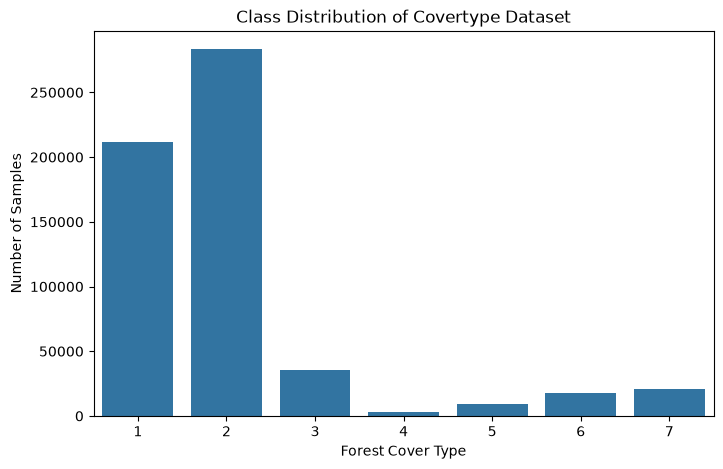

In [5]:
plt.figure(figsize=(8, 5))

sns.barplot(
    x=class_counts.index,
    y=class_counts.values
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("Class Distribution of Covertype Dataset")
plt.show()

In [6]:
max_class = class_counts.max()
min_class = class_counts.min()

imbalance_ratio = max_class / min_class

print("Most frequent class:", max_class)
print("Least frequent class:", min_class)
print("Imbalance ratio:", imbalance_ratio)

Most frequent class: 283301
Least frequent class: 2747
Imbalance ratio: 103.13105205678923


In [7]:
y = y - 1

print("Classes after conversion:")
print(np.unique(y))

Classes after conversion:
[0 1 2 3 4 5 6]


In [8]:
num_classes = 7

Y = np.eye(num_classes)[y]

print("One-hot encoded target shape:", Y.shape)
print("\nFirst 5 targets:")
print(Y[:5])

One-hot encoded target shape: (581012, 7)

First 5 targets:
[[0. 0. 0. 0. 1. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 1. 0. 0. 0. 0. 0.]
 [0. 0. 0. 0. 1. 0. 0.]]


In [9]:
X_train, X_temp, Y_train, Y_temp, y_train, y_temp = train_test_split(
    X,
    Y,
    y,
    test_size=0.20,
    random_state=42,
    stratify=y
)

In [10]:
X_val, X_test, Y_val, Y_test, y_val, y_test = train_test_split(
    X_temp,
    Y_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training:", X_train.shape)
print("Validation:", X_val.shape)
print("Testing:", X_test.shape)

Training: (464809, 54)
Validation: (58101, 54)
Testing: (58102, 54)


In [11]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

print("Feature standardization completed!")

Feature standardization completed!


In [12]:
N = len(y_train)
K = 7

class_weights = {}

for c in range(K):
    class_count = np.sum(y_train == c)
    class_weights[c] = N / (K * class_count)

print("Class Weights:")

for c, weight in class_weights.items():
    print("Class", c, ":", weight)

Class Weights:
Class 0 : 0.39181272253992233
Class 1 : 0.29298131712974634
Class 2 : 2.3214797648598298
Class 3 : 30.209866112049916
Class 4 : 8.743914368486399
Class 5 : 4.779133850171708
Class 6 : 4.046884794873581


In [13]:
def relu(z0):
    return np.maxium(0,z)


In [14]:
def relu_derivative(z):
    return (z > 0).astype(float)

In [15]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

In [16]:
np.random.seed(42)

W1 = np.random.randn(54, 64) * np.sqrt(2 / 54)
b1 = np.zeros((1, 64))

W2 = np.random.randn(64, 32) * np.sqrt(2 / 64)
b2 = np.zeros((1, 32))

W3 = np.random.randn(32, 16) * np.sqrt(2 / 32)
b3 = np.zeros((1, 16))

W4 = np.random.randn(16, 7) * np.sqrt(2 / 16)
b4 = np.zeros((1, 7))

print("Network parameters initialized!")

Network parameters initialized!


In [17]:
def forward(X):
    
    Z1 = X @ W1 + b1
    A1 = relu(Z1)
    
    Z2 = A1 @ W2 + b2
    A2 = relu(Z2)
    
    Z3 = A2 @ W3 + b3
    A3 = relu(Z3)
    
    Z4 = A3 @ W4 + b4
    Y_hat = softmax(Z4)
    
    cache = (X, Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat)
    
    return Y_hat, cache

In [18]:
def compute_loss(Y, Y_hat, y_labels):
    
    weights = np.array([class_weights[c] for c in y_labels])
    
    loss = -np.mean(
        weights * np.sum(Y * np.log(Y_hat + 1e-8), axis=1)
    )
    
    return loss

In [19]:
def backward(Y, y_labels, cache):
    
    global W1, b1, W2, b2, W3, b3, W4, b4
    
    X, Z1, A1, Z2, A2, Z3, A3, Z4, Y_hat = cache
    
    batch_size = X.shape[0]
    
    weights = np.array([class_weights[c] for c in y_labels])
    
    # Output layer gradient
    dZ4 = (Y_hat - Y) * weights.reshape(-1, 1)
    dZ4 /= batch_size
    
    dW4 = A3.T @ dZ4
    db4 = np.sum(dZ4, axis=0, keepdims=True)
    
    # Hidden layer 3
    dA3 = dZ4 @ W4.T
    dZ3 = dA3 * relu_derivative(Z3)
    
    dW3 = A2.T @ dZ3
    db3 = np.sum(dZ3, axis=0, keepdims=True)
    
    # Hidden layer 2
    dA2 = dZ3 @ W3.T
    dZ2 = dA2 * relu_derivative(Z2)
    
    dW2 = A1.T @ dZ2
    db2 = np.sum(dZ2, axis=0, keepdims=True)
    
    # Hidden layer 1
    dA1 = dZ2 @ W2.T
    dZ1 = dA1 * relu_derivative(Z1)
    
    dW1 = X.T @ dZ1
    db1 = np.sum(dZ1, axis=0, keepdims=True)
    
    return dW1, db1, dW2, db2, dW3, db3, dW4, db4

In [20]:
def predict(X):
    
    Y_hat, _ = forward(X)
    
    predictions = np.argmax(Y_hat, axis=1)
    
    return predictions

In [21]:
def calculate_accuracy(X, y):
    
    predictions = predict(X)
    
    return np.mean(predictions == y)

In [22]:
learning_rate = 0.01
batch_size = 128

epochs = 50

patience = 15

best_val_loss = float("inf")
patience_counter = 0

train_losses = []
val_losses = []

train_accuracies = []
val_accuracies = []

print("Training parameters set!")

Training parameters set!


In [27]:
for epoch in range(epochs):
    
    # Shuffle training data
    indices = np.random.permutation(len(X_train))
    
    X_train_shuffled = X_train[indices]
    Y_train_shuffled = Y_train[indices]
    y_train_shuffled = y_train[indices]
    
    epoch_loss = 0
    num_batches = 0
    
    # Mini-batch training
    for start in range(0, len(X_train), batch_size):
        
        end = start + batch_size
        
        X_batch = X_train_shuffled[start:end]
        Y_batch = Y_train_shuffled[start:end]
        y_batch = y_train_shuffled[start:end]
        
        # Forward propagation
        Y_hat, cache = forward(X_batch)
        
        # Loss
        loss = compute_loss(Y_batch, Y_hat, y_batch)
        
        # Backpropagation
        gradients = backward(Y_batch, y_batch, cache)
        
        dW1, db1, dW2, db2, dW3, db3, dW4, db4 = gradients
        
        # Parameter updates
        W1 -= learning_rate * dW1
        b1 -= learning_rate * db1
        
        W2 -= learning_rate * dW2
        b2 -= learning_rate * db2
        
        W3 -= learning_rate * dW3
        b3 -= learning_rate * db3
        
        W4 -= learning_rate * dW4
        b4 -= learning_rate * db4
        
        epoch_loss += loss
        num_batches += 1
    
    epoch_loss /= num_batches
    
    # Validation
    val_predictions_prob, _ = forward(X_val)
    
    val_loss = compute_loss(
        Y_val,
        val_predictions_prob,
        y_val
    )
    
    train_accuracy = calculate_accuracy(X_train[:10000], y_train[:10000])
    val_accuracy = calculate_accuracy(X_val[:10000], y_val[:10000])
    
    train_losses.append(epoch_loss)
    val_losses.append(val_loss)
    
    train_accuracies.append(train_accuracy)
    val_accuracies.append(val_accuracy)
    
    print(
        f"Epoch {epoch + 1}/{epochs} | "
        f"Train Loss: {epoch_loss:.4f} | "
        f"Val Loss: {val_loss:.4f} | "
        f"Train Acc: {train_accuracy:.4f} | "
        f"Val Acc: {val_accuracy:.4f}"
    )
    
    # Early stopping
    if val_loss < best_val_loss:
        
        best_val_loss = val_loss
        patience_counter = 0
        
        best_W1 = W1.copy()
        best_b1 = b1.copy()
        best_W2 = W2.copy()
        best_b2 = b2.copy()
        best_W3 = W3.copy()
        best_b3 = b3.copy()
        best_W4 = W4.copy()
        best_b4 = b4.copy()
        
    else:
        
        patience_counter += 1
        
        if patience_counter >= patience:
            
            print("Early stopping triggered.")
            break

Epoch 1/50 | Train Loss: 0.9190 | Val Loss: 0.7079 | Train Acc: 0.5894 | Val Acc: 0.5919
Epoch 2/50 | Train Loss: 0.6556 | Val Loss: 0.6260 | Train Acc: 0.6321 | Val Acc: 0.6349
Epoch 3/50 | Train Loss: 0.6029 | Val Loss: 0.6164 | Train Acc: 0.6686 | Val Acc: 0.6713
Epoch 4/50 | Train Loss: 0.5719 | Val Loss: 0.5690 | Train Acc: 0.6634 | Val Acc: 0.6657
Epoch 5/50 | Train Loss: 0.5512 | Val Loss: 0.5439 | Train Acc: 0.6748 | Val Acc: 0.6799
Epoch 6/50 | Train Loss: 0.5365 | Val Loss: 0.5488 | Train Acc: 0.6709 | Val Acc: 0.6806
Epoch 7/50 | Train Loss: 0.5227 | Val Loss: 0.5231 | Train Acc: 0.6693 | Val Acc: 0.6792
Epoch 8/50 | Train Loss: 0.5105 | Val Loss: 0.5124 | Train Acc: 0.6935 | Val Acc: 0.7033
Epoch 9/50 | Train Loss: 0.5009 | Val Loss: 0.5131 | Train Acc: 0.6984 | Val Acc: 0.7064
Epoch 10/50 | Train Loss: 0.4904 | Val Loss: 0.4984 | Train Acc: 0.6938 | Val Acc: 0.7022
Epoch 11/50 | Train Loss: 0.4800 | Val Loss: 0.5018 | Train Acc: 0.6937 | Val Acc: 0.6979
Epoch 12/50 | Train

In [24]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [25]:
print(np.__version__)
print(np.__file__)
print(hasattr(np, "maximum"))

2.5.3
c:\Users\Admin\Desktop\lab_prg\.venv\Lib\site-packages\numpy\__init__.py
True


In [26]:
def relu(z):
    return np.maximum(0, z)

print(relu(np.array([-2, -1, 0, 2, 5])))

[0 0 0 2 5]


In [28]:
W1 = best_W1
b1 = best_b1

W2 = best_W2
b2 = best_b2

W3 = best_W3
b3 = best_b3

W4 = best_W4
b4 = best_b4

print("Best model restored!")

Best model restored!


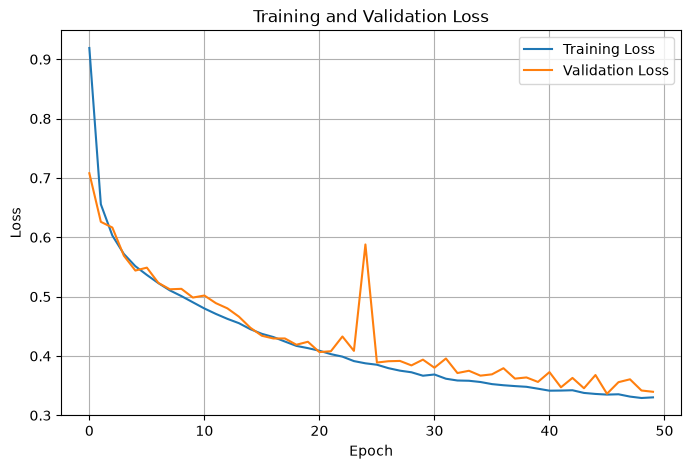

In [29]:
plt.figure(figsize=(8, 5))

plt.plot(train_losses, label="Training Loss")
plt.plot(val_losses, label="Validation Loss")

plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training and Validation Loss")

plt.legend()
plt.grid()

plt.show()

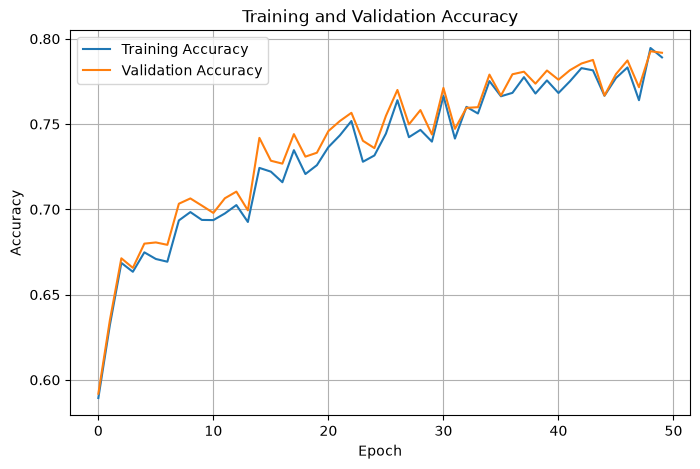

In [30]:
plt.figure(figsize=(8, 5))

plt.plot(train_accuracies, label="Training Accuracy")
plt.plot(val_accuracies, label="Validation Accuracy")

plt.xlabel("Epoch")
plt.ylabel("Accuracy")
plt.title("Training and Validation Accuracy")

plt.legend()
plt.grid()

plt.show()

In [31]:
test_probabilities, _ = forward(X_test)

y_pred = np.argmax(test_probabilities, axis=1)

print("Predictions generated successfully!")
print("First 20 predictions:")
print(y_pred[:20])

Predictions generated successfully!
First 20 predictions:
[0 1 1 0 5 4 1 1 1 4 1 3 1 0 0 2 0 0 4 0]


In [32]:
test_accuracy = accuracy_score(y_test, y_pred)

print("Test Accuracy:", test_accuracy)
print("Test Accuracy (%):", test_accuracy * 100)

Test Accuracy: 0.7772882172730715
Test Accuracy (%): 77.72882172730715


In [33]:
precision = precision_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Precision:", precision)

Macro Precision: 0.6505794233002289


In [34]:
recall = recall_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro Recall:", recall)

Macro Recall: 0.8742900278636697


In [35]:
f1 = f1_score(
    y_test,
    y_pred,
    average="macro",
    zero_division=0
)

print("Macro F1 Score:", f1)

Macro F1 Score: 0.716319087162781


In [36]:
print("Classification Report:\n")

print(
    classification_report(
        y_test,
        y_pred,
        target_names=[
            "Spruce/Fir",
            "Lodgepole Pine",
            "Ponderosa Pine",
            "Cottonwood/Willow",
            "Aspen",
            "Douglas-fir",
            "Krummholz"
        ],
        zero_division=0
    )
)

Classification Report:

                   precision    recall  f1-score   support

       Spruce/Fir       0.79      0.79      0.79     21184
   Lodgepole Pine       0.86      0.73      0.79     28331
   Ponderosa Pine       0.80      0.80      0.80      3576
Cottonwood/Willow       0.50      0.98      0.66       274
            Aspen       0.27      0.98      0.43       949
      Douglas-fir       0.61      0.85      0.71      1737
        Krummholz       0.71      0.98      0.83      2051

         accuracy                           0.78     58102
        macro avg       0.65      0.87      0.72     58102
     weighted avg       0.81      0.78      0.79     58102



In [37]:
cm = confusion_matrix(y_test, y_pred)

print("Confusion Matrix:")
print(cm)

Confusion Matrix:
[[16835  3310    28     0   291    20   700]
 [ 4344 20775   477     4  2110   514   107]
 [    0    29  2871   209    60   407     0]
 [    0     0     4   269     0     1     0]
 [    3     6     4     0   930     6     0]
 [    0    12   188    55    10  1472     0]
 [   40     1     0     0     0     0  2010]]


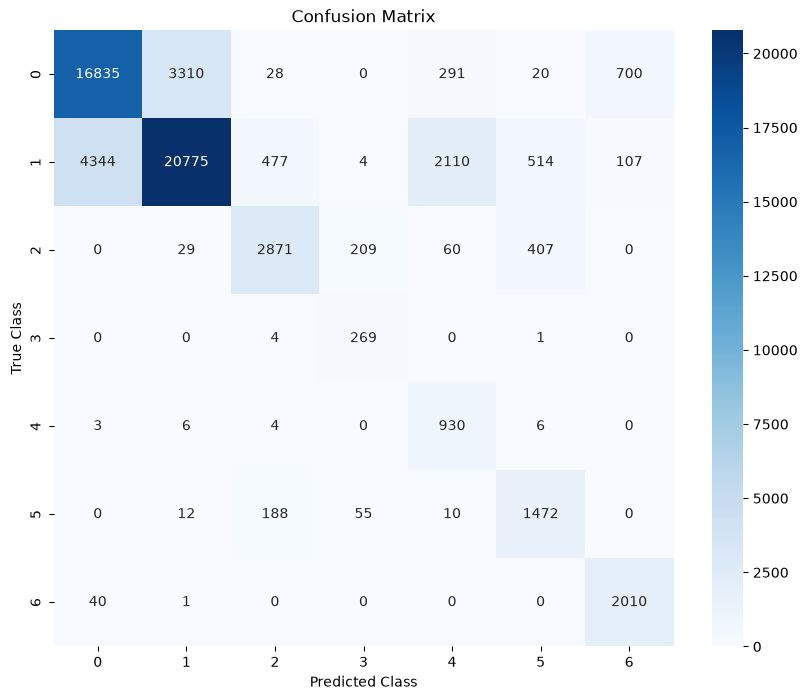

In [38]:
plt.figure(figsize=(10, 8))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.xlabel("Predicted Class")
plt.ylabel("True Class")
plt.title("Confusion Matrix")

plt.show()

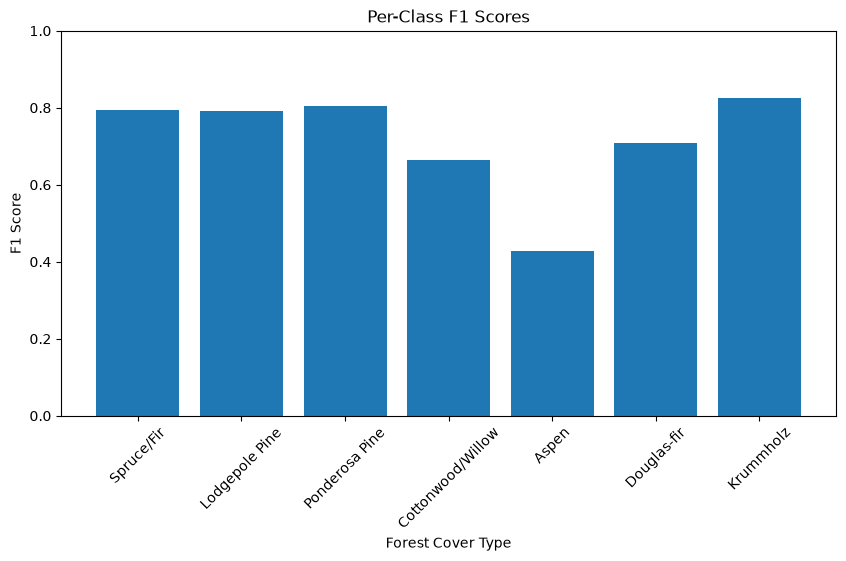

In [39]:
class_names = [
    "Spruce/Fir",
    "Lodgepole Pine",
    "Ponderosa Pine",
    "Cottonwood/Willow",
    "Aspen",
    "Douglas-fir",
    "Krummholz"
]

f1_scores = f1_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

plt.figure(figsize=(10, 5))

plt.bar(class_names, f1_scores)

plt.xlabel("Forest Cover Type")
plt.ylabel("F1 Score")
plt.title("Per-Class F1 Scores")

plt.xticks(rotation=45)
plt.ylim(0, 1)

plt.show()

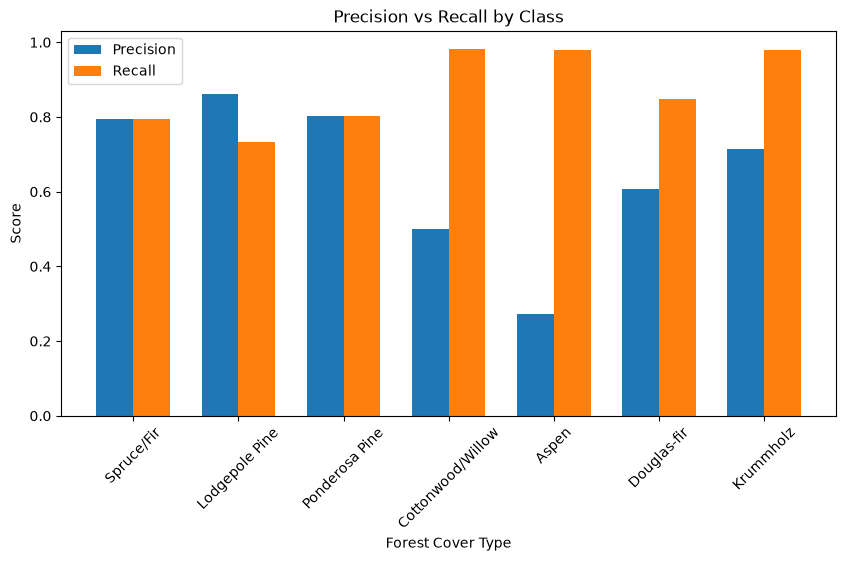

In [40]:
precision_scores = precision_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

recall_scores = recall_score(
    y_test,
    y_pred,
    average=None,
    zero_division=0
)

x = np.arange(len(class_names))

width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    precision_scores,
    width,
    label="Precision"
)

plt.bar(
    x + width / 2,
    recall_scores,
    width,
    label="Recall"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Score")
plt.title("Precision vs Recall by Class")

plt.xticks(x, class_names, rotation=45)

plt.legend()

plt.show()

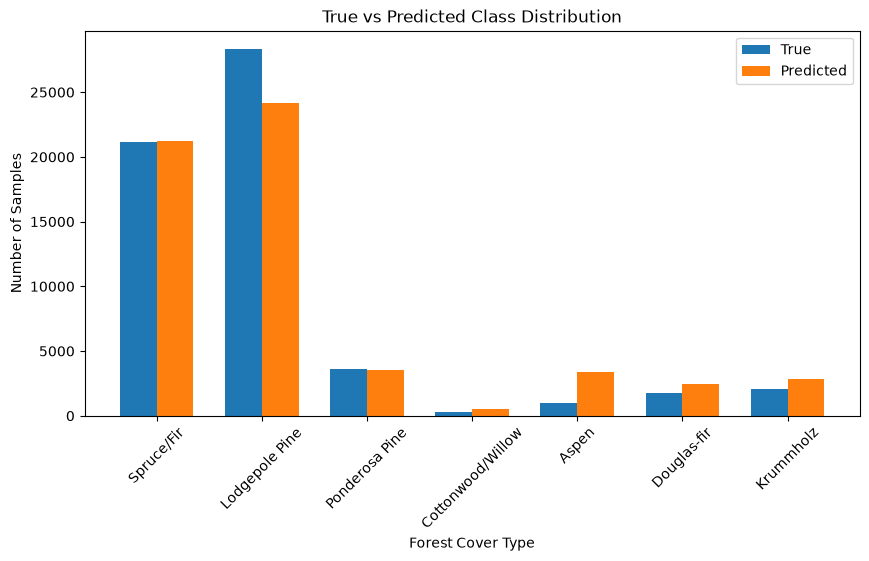

In [41]:
true_counts = np.bincount(y_test, minlength=7)
pred_counts = np.bincount(y_pred, minlength=7)

x = np.arange(7)
width = 0.35

plt.figure(figsize=(10, 5))

plt.bar(
    x - width / 2,
    true_counts,
    width,
    label="True"
)

plt.bar(
    x + width / 2,
    pred_counts,
    width,
    label="Predicted"
)

plt.xlabel("Forest Cover Type")
plt.ylabel("Number of Samples")
plt.title("True vs Predicted Class Distribution")

plt.xticks(x, class_names, rotation=45)

plt.legend()

plt.show()

In [42]:
print("========== FINAL RESULTS ==========")

print(f"Test Accuracy  : {test_accuracy:.4f}")
print(f"Macro Precision: {precision:.4f}")
print(f"Macro Recall   : {recall:.4f}")
print(f"Macro F1 Score : {f1:.4f}")

print("===================================")

========== FINAL RESULTS ==========
Test Accuracy  : 0.7773
Macro Precision: 0.6506
Macro Recall   : 0.8743
Macro F1 Score : 0.7163


In [43]:
parameters = (
    W1.size + b1.size +
    W2.size + b2.size +
    W3.size + b3.size +
    W4.size + b4.size
)

print("Total trainable parameters:", parameters)

Total trainable parameters: 6247
